# 45 Ann for Regression

In [5]:
# import libraries
import numpy as np
import matplotlib.pyplot as plt
import matplotlib_inline.backend_inline

# set the backend for matplotlib
matplotlib_inline.backend_inline.set_matplotlib_formats('svg', 'png')

In [44]:
# import pytorch
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"using device: {device}")

using device: cuda


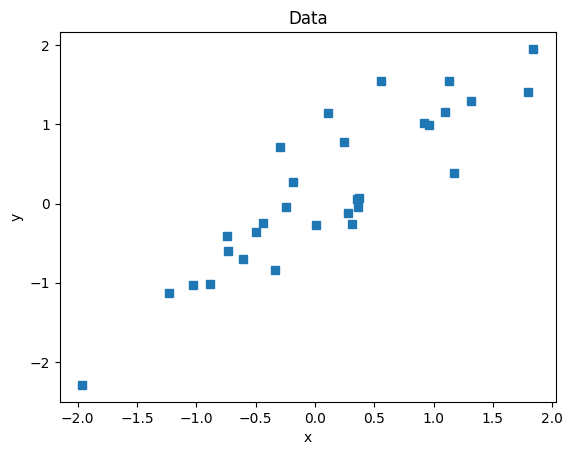

In [45]:
# create data
N = 30
x = torch.randn(N, 1)
y = x + torch.randn(N, 1) * 0.5

# plot data
plt.plot(x,y,'s')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Data')
plt.show()

In [46]:
# Build a linear regression model
ANNreg = torch.nn.Sequential(
    torch.nn.Linear(1, 1),
    torch.nn.ReLU(),
    torch.nn.Linear(1, 1)
)
# print the model
print(ANNreg)

Sequential(
  (0): Linear(in_features=1, out_features=1, bias=True)
  (1): ReLU()
  (2): Linear(in_features=1, out_features=1, bias=True)
)


In [47]:
# learning rate
learning_rate = 0.05

# loss function
loss_fn = torch.nn.MSELoss()

# optimizer
optimizer = torch.optim.SGD(ANNreg.parameters(), lr=learning_rate)


In [48]:
# train the model
epochs = 500
losses = torch.zeros(epochs)

## training loop
for epochs in range(epochs):
    # forward pass
    y_pred = ANNreg(x)

    # compute loss
    loss = loss_fn(y_pred, y)
    losses[epochs] = loss

    # backward pass (backpropagation)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

test loss: 0.2096


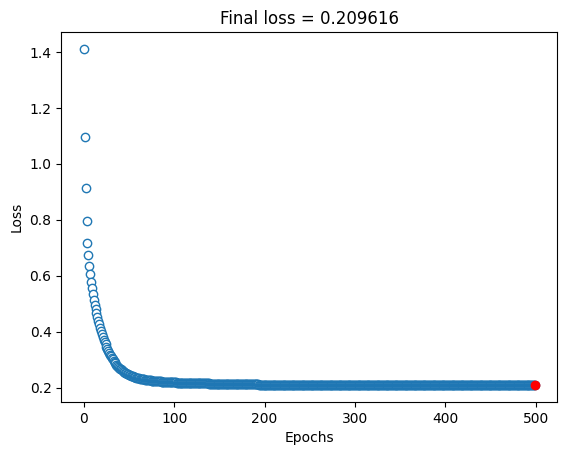

In [49]:
# plot the losses

predictions = ANNreg(x)

testloss = (predictions - y).pow(2).mean()
print(f"test loss: {testloss.detach().item():.4f}")

plt.plot(losses.detach(), 'o', markerfacecolor='w', linewidth=.1)
plt.plot(epochs, testloss.detach(), 'ro')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Final loss = %g' %testloss.detach().item())
plt.show()

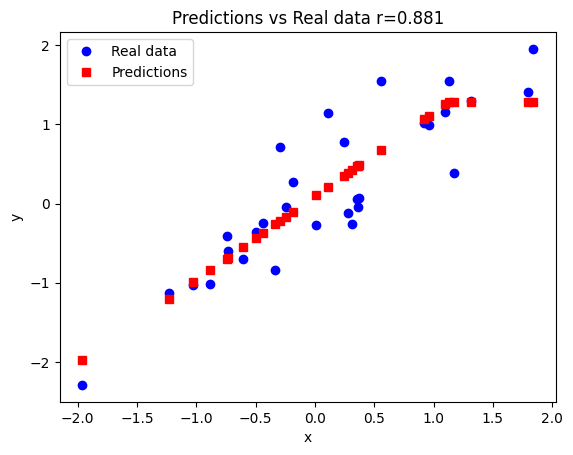

In [50]:
# plot the data with the predictions
plt.plot(x,y, 'bo', label='Real data')
plt.plot(x, predictions.detach().numpy(), 'rs', label='Predictions')
plt.title(f'Predictions vs Real data r={np.corrcoef(y.T, predictions.detach().T)[0,1]:.3f}')
plt.legend()
plt.xlabel('x')
plt.ylabel('y')
plt.show()